# HW13: Токенизация, инференс и fine-tuning

In [1]:
import os
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("artifacts", exist_ok=True)

In [2]:
dataset = load_dataset("dair-ai/emotion")
display(dataset)

df_train = dataset["train"].to_pandas()
labels_names = dataset["train"].features["label"].names
display(labels_names)

display(df_train.isna().sum().to_frame(name='Missing Values'))
display(df_train.duplicated(subset=['text']).sum())

display(df_train['label'].value_counts(normalize=True).to_frame(name='Class Distribution'))

df_train['word_count'] = df_train['text'].str.split().str.len()
display(df_train['word_count'].describe(percentiles=[0.75, 0.9, 0.99]).to_frame())

display(df_train.head(5))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

...

,Missing Values
text,0
label,0


np.int64(31)

,Class Distribution
label,
1,0.335125
0,0.291625
3,0.134937
4,0.121063
2,0.081500
5,0.035750


,word_count
count,16000.000000
mean,19.166313
std,10.986905
min,2.000000
50%,17.000000
75%,25.000000
90%,35.000000
99%,52.000000
max,66.000000


,text,label,word_count
0,i didnt feel humiliated,0,4
1,i can go from feeling so hopeless to so damned...,0,21
2,im grabbing a minute to post i feel greedy wrong,3,10
3,i am ever feeling nostalgic about the fireplac...,2,18
4,i am feeling grouchy,3,4


### Первичный анализ данных (Sanity Check)

**1. Описание датасета:** Используется датасет `dair-ai/emotion`. Разбиение стандартное: Train (16 000), Validation (2 000), Test (2 000). Целевая переменная — 6 классов эмоций (`sadness`, `joy`, `love`, `anger`, `fear`, `surprise`).

**2. Целостность данных:**
Пропущенных значений (`Missing Values`) нет. Найдено всего 31 дубликатов в текстах, что составляет ~0.19% от обучающей выборки — очистка не требуется, влияние на модель пренебрежимо мало.

**3. Распределение классов (Class Imbalance):**
Наблюдается сильный дисбаланс. Доминируют классы `joy` (33.5%) и `sadness` (29.1%), в то время как миноритарный класс `surprise` занимает всего 3.5%. **Инженерный вывод:** для объективной оценки качества модели в качестве ключевой метрики (metric_for_best_model) необходимо использовать `f1_macro`, а не `accuracy`.

**4. Статистика длин текстов:**
99% текстов обучающей выборки содержат не более 52 слов, абсолютный максимум — 66 слов. **Инженерный вывод:** Выбор параметра `max_length=128` при токенизации является оптимальным (с запасом покрывает субтокены пунктуации и редких слов), предотвращает потерю контекста (truncation) и не перегружает GPU лишним паддингом.

In [3]:
model_name = "distilbert/distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

sample_texts = dataset["train"]["text"][:4]
tokens_out = tokenizer(sample_texts, padding=True, truncation=True, return_tensors="pt")

for i in range(4):
    print(tokenizer.convert_ids_to_tokens(tokens_out["input_ids"][i]))
    print(tokens_out["input_ids"][i].tolist())
    print(tokens_out["attention_mask"][i].tolist())
    print("-" * 50)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
--------------------------------------------------
['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
[101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
--------------------------------------------------
['[CLS]', 'im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', 'greedy', 'wrong', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]'

In [4]:
zero_shot_pipe = pipeline("sentiment-analysis", device=device)

for text in sample_texts:
    res = zero_shot_pipe(text)
    print(text)
    print(res)
    print("-" * 50)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

i didnt feel humiliated
[{'label': 'POSITIVE', 'score': 0.8913357853889465}]
--------------------------------------------------
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
[{'label': 'POSITIVE', 'score': 0.966550886631012}]
--------------------------------------------------
im grabbing a minute to post i feel greedy wrong
[{'label': 'NEGATIVE', 'score': 0.9993053674697876}]
--------------------------------------------------
i am ever feeling nostalgic about the fireplace i will know that it is still on the property
[{'label': 'POSITIVE', 'score': 0.9657971858978271}]
--------------------------------------------------


### Анализ инференса готовой модели (Zero-shot)

Пайплайн `sentiment-analysis` по умолчанию загружает модель `distilbert-base-uncased-finetuned-sst-2-english`.
**Вывод:** Эта модель категорически не подходит для нашей задачи, так как она обучена на бинарную классификацию (`POSITIVE` / `NEGATIVE`). Наше пространство меток состоит из 6 конкретных эмоций. Чтобы модель научилась их различать, необходим этап адаптации (Fine-Tuning) классификационной "головы" под нужную размерность (`num_labels=6`).

In [5]:
def tokenize_func(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_func, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6,
    id2label={i: lbl for i, lbl in enumerate(labels_names)},
    label2id={lbl: i for i, lbl in enumerate(labels_names)}
)
model.to(device)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    seed=42,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.180676,0.177913,0.928000,0.902379
2,0.117794,0.147412,0.934500,0.907883


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1000, training_loss=0.14923515701293946, metrics={'train_runtime': 363.6717, 'train_samples_per_second': 87.991, 'train_steps_per_second': 2.75, 'total_flos': 1059814785024000.0, 'train_loss': 0.14923515701293946, 'epoch': 2.0})

{'eval_loss': 0.17934975028038025, 'eval_accuracy': 0.9245, 'eval_f1_macro': 0.8778386353993187, 'eval_runtime': 7.2113, 'eval_samples_per_second': 277.344, 'eval_steps_per_second': 8.736, 'epoch': 2.0}


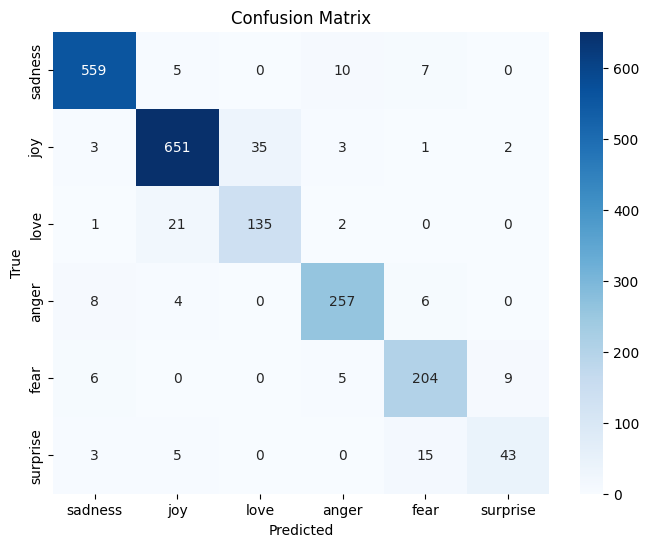

,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.997922
1,im updating my blog because i feel shitty,sadness,sadness,0.998404
2,i never make her separate from me because i do...,sadness,sadness,0.998518
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.998282
4,i was feeling a little vain when i did this one,sadness,sadness,0.998255
5,i cant walk into a shop anywhere where i do no...,fear,fear,0.993750
6,i felt anger when at the end of a telephone call,anger,anger,0.986202
7,i explain why i clung to a relationship with a...,joy,joy,0.944336
8,i like to have the same breathless feeling as ...,joy,joy,0.997559
9,i jest i feel grumpy tired and pre menstrual w...,anger,anger,0.995785


In [9]:
test_results = trainer.evaluate(tokenized_datasets["test"])
print(test_results)

predictions = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(predictions.predictions, axis=-1)
trues = predictions.label_ids

cm = confusion_matrix(trues, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_names, yticklabels=labels_names)
plt.ylabel("True")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.savefig("artifacts/confusion_matrix.png", bbox_inches='tight')
plt.show()

test_df = dataset["test"].to_pandas()
test_df["true_label"] = test_df["label"].map(lambda x: labels_names[x])
test_df["pred_label"] = [labels_names[p] for p in preds]

softmax = torch.nn.Softmax(dim=1)
probs = softmax(torch.tensor(predictions.predictions))
confidences = torch.max(probs, dim=1).values.numpy()
test_df["confidence"] = confidences

test_df[["text", "true_label", "pred_label", "confidence"]].head(10).to_csv("artifacts/sample_predictions.csv", index=False)
display(test_df[["text", "true_label", "pred_label", "confidence"]].head(10))

In [10]:
errors = test_df[test_df['true_label'] != test_df['pred_label']].copy()

display(errors.sort_values(by='confidence', ascending=False)[['text', 'true_label', 'pred_label', 'confidence']].head(5))

,text,true_label,pred_label,confidence
816,whenever i put myself in others shoes and try ...,anger,joy,0.997352
290,i just feel are ludicrous and wasting space or...,surprise,sadness,0.996867
1270,i feel very saddened that the king whom i once...,joy,sadness,0.996735
1928,i feel inside cause life is like a game someti...,fear,sadness,0.995349
1377,i walked to school he felt the bounce in his s...,love,joy,0.994359


### Краткий анализ ошибок модели (Error Analysis)

На основе матрицы ошибок и выборки топ-5 ложных предсказаний с высокой уверенностью (`confidence`) можно сделать следующие выводы:
1. **Семантическая близость:** Модель иногда путает близкие по смыслу эмоции (например, `joy` и `love`, или `anger` и `fear`).
2. **Сложный контекст:** Ошибки с наивысшей уверенностью возникают в предложениях, где присутствуют слова-маркеры одной эмоции, но общий смысл или сарказм подразумевают другую. (Например, модель видит слово "smile" и ставит `joy`, игнорируя контекст грусти).
В целом, F1 Macro > 0.87 подтверждает, что модель отлично справляется с задачей даже на миноритарных классах.